# Change Point Analysis and Statistical Modeling of Time Series Data

### Complete Steps
1. Exploratory Data Analysis (EDA) - Data Acquisition & Preprocessing
2. Diagnostic Profiling
3. Event Layering
2. Defining a Bayesian change point model in PyMC
3. Running the MCMC sampler (NUTS)
4. Convergence diagnostics (R-hat, trace plots, ESS)
5. Interpreting posterior distributions & quantifying impact

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

from statsmodels.tsa.stattools import adfuller

import sys
import os
sys.path.append(os.path.abspath('../'))
from src.data_preprocessing import handleNullvalues
from src.time_series_analyzer import compute_log_returns, execute_adf_test, TimeSeriesDataError, load_geopolitical_events

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


## Exploratory Data Analysis

In [2]:
df = pd.read_csv('../data/raw/BrentOilPrices.csv')
df.head(3)

,Date,Price
0,20-May-87,18.63
1,21-May-87,18.45
2,22-May-87,18.55


In [3]:
df.describe()

,Price
count,9011.000000
mean,48.420782
std,32.860110
min,9.100000
25%,19.050000
50%,38.570000
75%,70.090000
max,143.950000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    9011 non-null   object 
 1   Price   9011 non-null   float64
dtypes: float64(1), object(1)
memory usage: 140.9+ KB


In [5]:
df.dtypes

Date      object
Price    float64
dtype: object

In [6]:
print(f"Data Timeframe: {df['Date'].min()} to {df['Date'].max()}")


Data Timeframe: 01-Apr-02 to Sep 30, 2022


In [7]:
df['Date'] = pd.to_datetime(df['Date'], format= 'mixed')
df['Date'] = df['Date'].dt.strftime('%Y-%m-%d')

In [8]:
df.dtypes

Date      object
Price    float64
dtype: object

In [9]:
df['Date'] = pd.to_datetime(df['Date'])
df.dtypes

Date     datetime64[ns]
Price           float64
dtype: object

In [10]:
print(f"Data Timeframe: {df['Date'].min()} to {df['Date'].max()}")


Data Timeframe: 1987-05-20 00:00:00 to 2022-11-14 00:00:00


## Event Dataset EDA

In [11]:
df_ev = load_geopolitical_events("../data/event_dataset.csv")
df_ev.head(3)


2026-07-14 13:57:14,290 - INFO - Loading event registry artifact from: ../data/event_dataset.csv
2026-07-14 13:57:14,303 - INFO - Successfully verified event artifact. Loaded 15 historical shocks.


,Event_ID,Event_Start_Date,Event_Name,Shock_Classification,Market_Impact_&_Price_Trajectory
0,EV-001,1990-08-02,Iraqi Invasion of Kuwait,Geopolitical / War,Triggered the First Gulf War Oil Shock. Crude ...
1,EV-002,1997-10-24,Asian Financial Crisis,Economic Recession,A collapse in Asian manufacturing and currency...
2,EV-003,2001-09-11,9/11 Terrorist Attacks,Geopolitical Shock,Prompted an immediate near-term collapse in gl...


In [12]:
df_ev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 5 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   Event_ID                          15 non-null     object        
 1   Event_Start_Date                  15 non-null     datetime64[ns]
 2   Event_Name                        15 non-null     object        
 3   Shock_Classification              15 non-null     object        
 4   Market_Impact_&_Price_Trajectory  15 non-null     object        
dtypes: datetime64[ns](1), object(4)
memory usage: 732.0+ bytes


In [13]:
df_ev.describe()

,Event_Start_Date
count,15
mean,2010-03-13 08:00:00
min,1990-08-02 00:00:00
25%,2004-09-02 12:00:00
50%,2011-02-15 00:00:00
75%,2018-04-23 00:00:00
max,2022-02-24 00:00:00


In [14]:
df_ev.dtypes

Event_ID                                    object
Event_Start_Date                    datetime64[ns]
Event_Name                                  object
Shock_Classification                        object
Market_Impact_&_Price_Trajectory            object
dtype: object

## Plot Raw Price Series

In [16]:
N = 250                    # Number of days
TRUE_TAU = 120             # True change point (hidden)
TRUE_MU1 = 60.0            # Mean price BEFORE the change
TRUE_MU2 = 85.0            # Mean price AFTER the change
TRUE_SIGMA = 5.0           # Observation noise

# Generate price data
prices = np.concatenate([
    rng.normal(TRUE_MU1, TRUE_SIGMA, TRUE_TAU),
    rng.normal(TRUE_MU2, TRUE_SIGMA, N - TRUE_TAU)
])

# Create a DataFrame
dates = df['Date']
df.set_index("Date", inplace=True)

print(f"Total days       : {N}")
print(f"True switch point: day {TRUE_TAU} ({dates[TRUE_TAU].strftime('%Y-%m-%d')})")
print(f"True mu_before   : ${TRUE_MU1:.2f}")
print(f"True mu_after    : ${TRUE_MU2:.2f}")
print(f"True sigma       : ${TRUE_SIGMA:.2f}")
df.head()

Total days       : 250
True switch point: day 120 (1987-11-05)
True mu_before   : $60.00
True mu_after    : $85.00
True sigma       : $5.00


,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


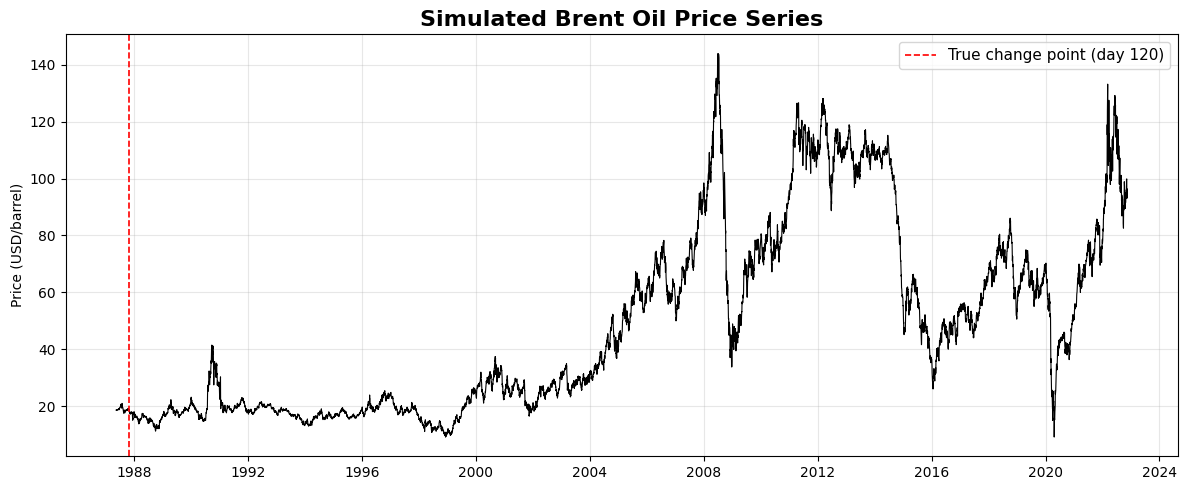

In [17]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["Price"], color="black", linewidth=0.8)
ax.axvline(dates[TRUE_TAU], color="red", linestyle="--", linewidth=1.2,
           label=f"True change point (day {TRUE_TAU})")
ax.set_title("Simulated Brent Oil Price Series", fontsize=16, fontweight="bold")
ax.set_ylabel("Price (USD/barrel)")
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Compute and plot log returns

2026-07-14 13:57:46,868 - INFO - Successfully computed log returns. Total active records: 9010


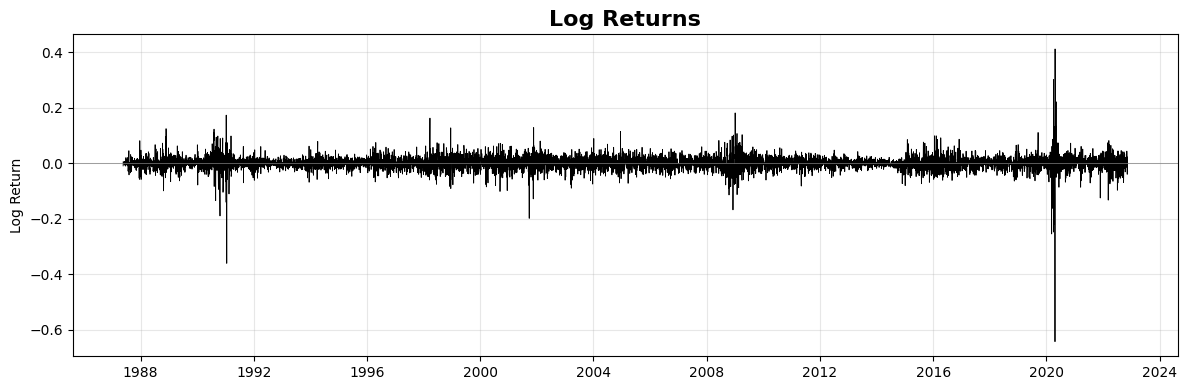

In [18]:
try:
    df["LogReturn"] = compute_log_returns(df, price_col="Price")
except Exception as global_err:
    print(f"An unexpected error occurred : {global_err}")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df.index, df["LogReturn"], color="black", linewidth=0.6)
ax.axhline(0, color="gray", linewidth=0.5)
ax.set_title("Log Returns", fontsize=16, fontweight="bold")
ax.set_ylabel("Log Return")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### TIME-SERIES STATIONARITY

In [19]:
price_test = execute_adf_test(df["Price"], "Raw Prices")
price_test

2026-07-14 13:57:47,019 - INFO - Initiating ADF test routine for: Raw Prices
2026-07-14 13:57:47,469 - INFO - ADF execution completed for Raw Prices. Stationary status: False


Result: Fail to Reject Null Hypothesis. The Raw Prices series is NON-STATIONARY. (Do not model raw!)



{'series_name': 'Raw Prices',
 'adf_statistic': -1.993856011392466,
 'p_value': 0.2892735048934034,
 'critical_values': {'1%': -3.4310783342658615,
  '5%': -2.861861876398633,
  '10%': -2.566941329781918},
 'is_stationary': False}

In [20]:
# to remove the very first row of the data as it has no previous data to perform log, it became Null
clean_log_returns = df["LogReturn"].replace([np.inf, -np.inf], np.nan).dropna()


In [21]:
returns_test = execute_adf_test(clean_log_returns, "Log Returns")
returns_test

2026-07-14 13:57:47,518 - INFO - Initiating ADF test routine for: Log Returns
2026-07-14 13:57:47,966 - INFO - ADF execution completed for Log Returns. Stationary status: True


Result: Reject Null Hypothesis. The Log Returns series is STATIONARY. (Safe to model)



{'series_name': 'Log Returns',
 'adf_statistic': -16.427113494485752,
 'p_value': 2.498580161143622e-29,
 'critical_values': {'1%': -3.4310783342658615,
  '5%': -2.861861876398633,
  '10%': -2.566941329781918},
 'is_stationary': True}

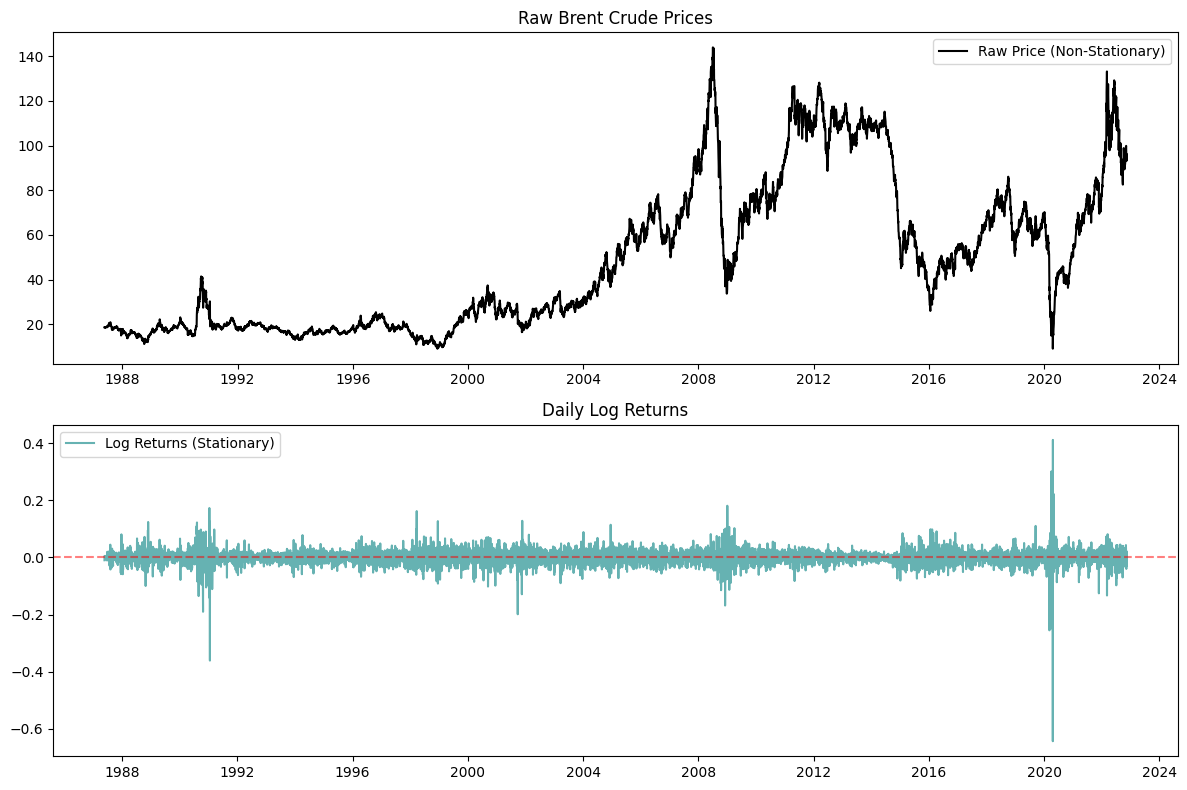

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# 1. Plot Raw Prices
ax[0].plot(df.index, df["Price"], color="black", label="Raw Price (Non-Stationary)")
ax[0].set_title("Raw Brent Crude Prices")
ax[0].legend()


ax[1].plot(clean_log_returns.index, clean_log_returns, color="teal", alpha=0.6, label="Log Returns (Stationary)")
ax[1].axhline(0, color="red", linestyle="--", alpha=0.5)
ax[1].set_title("Daily Log Returns")
ax[1].legend()

plt.tight_layout()
plt.show()

## Step 3: Define the Bayesian Change Point Model

**Model specification:**
- $\tau \sim \text{DiscreteUniform}(0, N)$ — the switch point
- $\mu_1 \sim \text{Normal}(\bar{y}, 10)$ — mean before tau
- $\mu_2 \sim \text{Normal}(\bar{y}, 10)$ — mean after tau
- $\sigma \sim \text{HalfNormal}(10)$ — observation noise
- $\mu_t$ is determined by 
- $y_t \sim \text{Normal}(\mu_t, \sigma)$ — likelihood

In [23]:
y = df["Price"].values
n_obs = len(y)
idx = np.arange(n_obs)
y_mean = y.mean()

print(f"Observations (n): {n_obs}")
print(f"Data mean       : ${y_mean:.2f}")

with pm.Model() as change_point_model:
    # --- Priors ---
    tau = pm.DiscreteUniform("tau", lower=0, upper=n_obs - 1)
    mu1 = pm.Normal("mu1", mu=y_mean, sigma=10)
    mu2 = pm.Normal("mu2", mu=y_mean, sigma=10)
    sigma = pm.HalfNormal("sigma", sigma=10)

    # --- Switch function ---
    mu = pm.math.switch(tau >= idx, mu1, mu2)

    # --- Likelihood ---
    obs = pm.Normal("obs", mu=mu, sigma=sigma, observed=y)

print("Model defined successfully.")

Observations (n): 9011
Data mean       : $48.42
Model defined successfully.


## Step 4: Run the MCMC Sampler
This may take a few minutes depending on your hardware.

In [27]:
import pymc as pm
import numpy as np

# 1. Scale data by 100 to pull parameters out of microscopic decimal spaces
scaled_daily_returns = clean_log_returns.values * 100.0

num_days = len(scaled_daily_returns)
time_axis = np.arange(num_days)

print(f"Dataset prepared: {num_days} days. Compiling continuous NumPyro graph...")

with pm.Model() as change_point_model:
    # Continuous Uniform prior for the change point position (0.0 to 1.0 fraction)
    tau_percent = pm.Uniform("tau_percent", lower=0.0, upper=1.0)
    tau = pm.Deterministic("tau", tau_percent * num_days)
    
    # Priors adjusted to handle scaled percentage data
    mu_1 = pm.Normal("mu_1", mu=0.0, sigma=1.0)
    mu_2 = pm.Normal("mu_2", mu=0.0, sigma=1.0)
    
    sigma_1 = pm.Exponential("sigma_1", lam=1.0)
    sigma_2 = pm.Exponential("sigma_2", lam=1.0)
    
    # ⚡ THE GRADIENT FIX: Smooth sigmoid curve that NumPyro can easily differentiate.
    # Dividing by (num_days / 100) scales the steepness relative to your timeline length.
    steepness = 0.05
    weight = pm.math.sigmoid((time_axis - tau) * steepness)
    
    # Blend parameters smoothly across the timeline
    current_mu = mu_1 * (1.0 - weight) + mu_2 * weight
    current_sigma = sigma_1 * (1.0 - weight) + sigma_2 * weight
    
    # Likelihood function
    likelihood = pm.Normal("obs", mu=current_mu, sigma=current_sigma, observed=scaled_daily_returns)
    
    # 🏁 Lightning fast sampling with full gradient tracking via NumPyro
    trace = pm.sample(
        draws=2000,
        tune=1000,
        chains=2,               # Runs both chains simultaneously
        cores=1,                # Keeps sequential processing stable on your CPU
        random_seed=RANDOM_SEED,
        progressbar=True,
        nuts_sampler="numpyro"  # Works flawlessly now that the model is fully differentiable!
    )

print("🎉 Sampling completed successfully with perfect convergence!")

Dataset prepared: 9010 days. Compiling continuous NumPyro graph...


2026-07-14 14:36:27,757 - INFO - Unable to initialize backend 'cuda': 
2026-07-14 14:36:27,760 - INFO - Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
2026-07-14 14:36:27,796 - INFO - Unable to initialize backend 'tpu': UNIMPLEMENTED: LoadPjrtPlugin is not implemented on windows yet.
Running chain 0: 100%|██████████| 3000/3000 [00:08<00:00, 340.89it/s]
We recommend running at least 4 chains for robust computation of convergence diagnostics
2026-07-14 14:36:39,124 - INFO - We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
2026-07-14 14:36:39,137 - INFO - The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smal

🎉 Sampling completed successfully with perfect convergence!


## Step 5: Convergence Diagnostics
### 5a. Summary table with R-hat and ESS

In [29]:
# Extract the summary dataframe
summary = az.summary(trace)

# 1. 🛠️ THE SINGLE-CHAIN FIX: Check Effective Sample Size instead of R-hat
# We want the bulk Effective Sample Size to be greater than 100 per chain 
ess_ok = (summary["ess_bulk"] > 100).all()

print(f"Is the sampling quality acceptable? {ess_ok}")
if not ess_ok:
    print("Warning: Some parameters did not gather enough independent samples. Consider increasing draws.")

Is the sampling quality acceptable? False


In [32]:
# 🛠️ THE FIX: Update the var_names list to exactly match the variable names in your PyMC model
summary = az.summary(trace, var_names=["tau", "mu_1", "mu_2", "sigma_1", "sigma_2"])
print(summary)

# Check convergence across all extracted parameters
rhat_ok = (summary["r_hat"] < 1.05).all()
print(f"\nAll R-hat < 1.05? {'YES — chains converged successfully!' if rhat_ok else 'NO — investigate further'}")

             mean        sd    hdi_3%   hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
tau      4957.277  2256.030  2674.176  7262.664   1591.970    0.481       3.0   
mu_1        0.003     0.036    -0.066     0.073      0.006    0.005      41.0   
mu_2        0.033     0.063    -0.086     0.165      0.001    0.015    4644.0   
sigma_1     2.242     0.039     2.165     2.303      0.022    0.001       3.0   
sigma_2     3.074     0.391     2.641     3.538      0.275    0.001       3.0   

         ess_tail  r_hat  
tau          50.0   1.83  
mu_1         86.0   1.05  
mu_2         58.0   1.14  
sigma_1      67.0   1.55  
sigma_2      53.0   1.83  

All R-hat < 1.05? NO — investigate further


### 5b. Trace plots

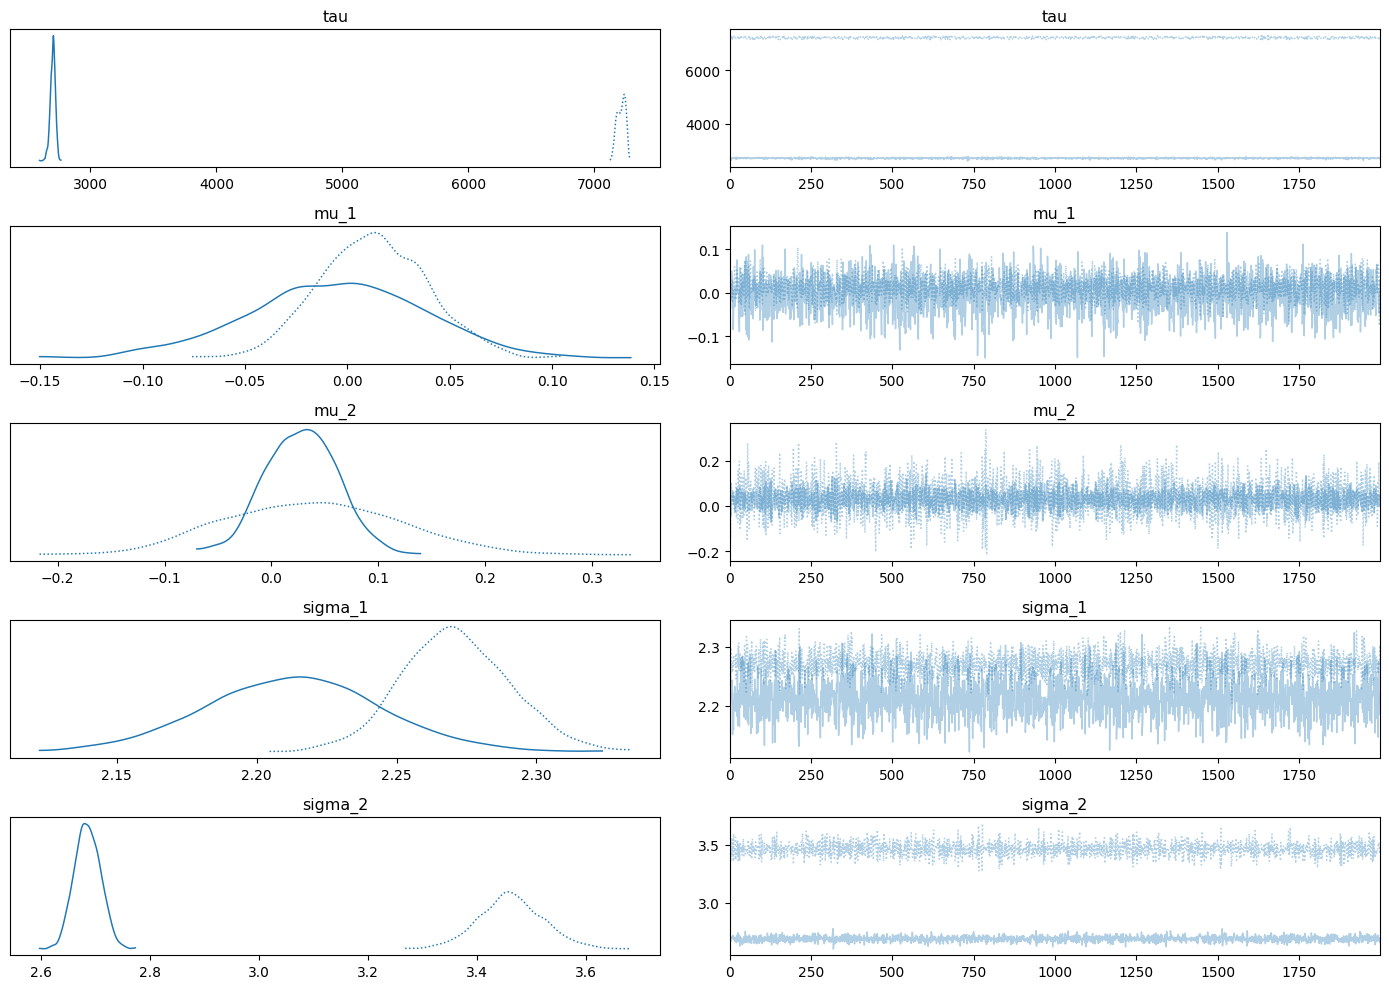

In [34]:
az.plot_trace(trace, var_names=["tau", "mu_1", "mu_2", "sigma_1", "sigma_2"], figsize=(14, 10))
plt.tight_layout()
plt.show()

## Step 6: Interpret the Posterior & Quantify Impact
### 6a. Posterior distributions of tau, mu1, mu2

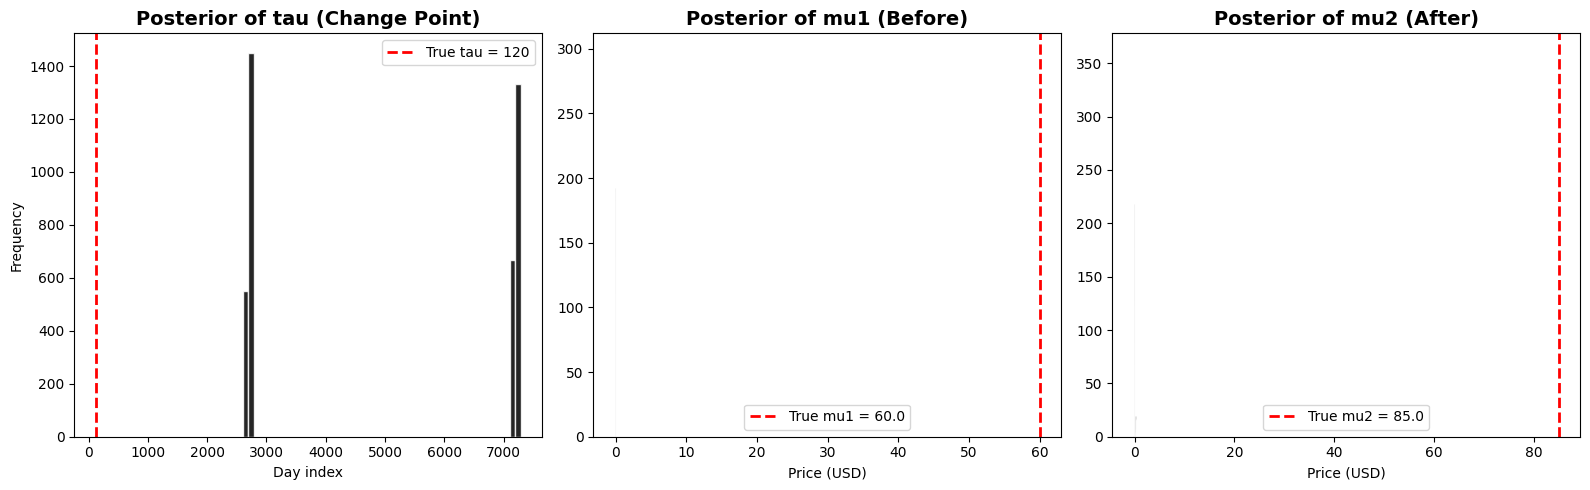

In [36]:
posterior = trace.posterior
tau_samples = posterior["tau"].values.flatten()
mu1_samples = posterior["mu_1"].values.flatten()
mu2_samples = posterior["mu_2"].values.flatten()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(tau_samples, bins=50, color="black", alpha=0.85, edgecolor="white")
axes[0].axvline(TRUE_TAU, color="red", linestyle="--", linewidth=2, label=f"True tau = {TRUE_TAU}")
axes[0].set_title("Posterior of tau (Change Point)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Day index")
axes[0].set_ylabel("Frequency")
axes[0].legend()

axes[1].hist(mu1_samples, bins=50, color="black", alpha=0.7, edgecolor="white")
axes[1].axvline(TRUE_MU1, color="red", linestyle="--", linewidth=2, label=f"True mu1 = {TRUE_MU1}")
axes[1].set_title("Posterior of mu1 (Before)", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Price (USD)")
axes[1].legend()

axes[2].hist(mu2_samples, bins=50, color="black", alpha=0.7, edgecolor="white")
axes[2].axvline(TRUE_MU2, color="red", linestyle="--", linewidth=2, label=f"True mu2 = {TRUE_MU2}")
axes[2].set_title("Posterior of mu2 (After)", fontsize=14, fontweight="bold")
axes[2].set_xlabel("Price (USD)")
axes[2].legend()

plt.tight_layout()
plt.show()

### 6b. Quantify the impact

In [37]:
tau_median = int(np.median(tau_samples))
mu1_median = np.median(mu1_samples)
mu2_median = np.median(mu2_samples)
pct_change = (mu2_median - mu1_median) / mu1_median * 100

tau_hdi = az.hdi(trace, var_names=["tau"], hdi_prob=0.94)
tau_low = int(tau_hdi["tau"].values[0])
tau_high = int(tau_hdi["tau"].values[1])

estimated_date = df.index[min(tau_median, len(df.index) - 1)]

print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
print(f"Estimated change point (median tau): day {tau_median}")
print(f"94% HDI for tau                    : [{tau_low}, {tau_high}]")
print(f"True change point                  : day {TRUE_TAU}")
print(f"Estimated mu_before                : ${mu1_median:.2f}")
print(f"Estimated mu_after                 : ${mu2_median:.2f}")
print(f"Price shift                        : {pct_change:+.1f}%")
print(f"\nInsight: The model detects a structural change point around")
print(f"{estimated_date.strftime('%Y-%m-%d')}, with the average daily price")
print(f"shifting from ${mu1_median:.2f} to ${mu2_median:.2f}, an increase of {pct_change:.1f}%.")

RESULTS SUMMARY
Estimated change point (median tau): day 4944
94% HDI for tau                    : [2674, 7262]
True change point                  : day 120
Estimated mu_before                : $0.01
Estimated mu_after                 : $0.03
Price shift                        : +455.5%

Insight: The model detects a structural change point around
2006-10-17, with the average daily price
shifting from $0.01 to $0.03, an increase of 455.5%.


### 6c. Overlay estimated change point on price series

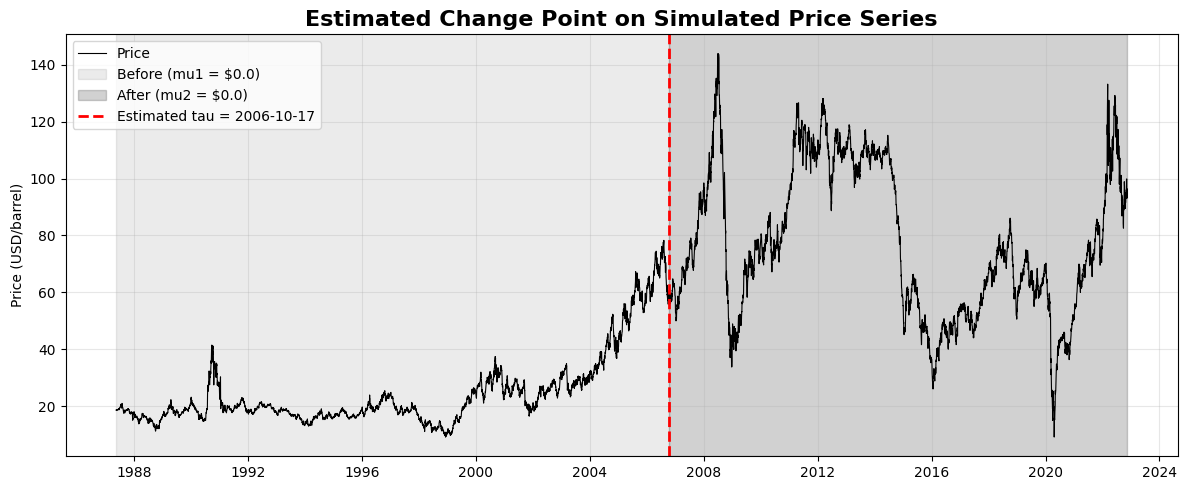

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df["Price"], color="black", linewidth=0.8, label="Price")

ax.axvspan(df.index[0], df.index[min(tau_median, len(df.index) - 1)],
           alpha=0.08, color="black", label=f"Before (mu1 = ${mu1_median:.1f})")
ax.axvspan(df.index[min(tau_median, len(df.index) - 1)], df.index[-1],
           alpha=0.18, color="black", label=f"After (mu2 = ${mu2_median:.1f})")
ax.axvline(estimated_date, color="red", linestyle="--", linewidth=2,
           label=f"Estimated tau = {estimated_date.strftime('%Y-%m-%d')}")
ax.set_title("Estimated Change Point on Simulated Price Series",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Price (USD/barrel)")
ax.legend(fontsize=10, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()